# Potato Disease Classification - MobileNetV2

Second model for the project. Same 3 potato classes from PlantVillage but using transfer learning with MobileNetV2 (pre-trained on ImageNet) instead of the custom CNN we used before.

Goal: get higher accuracy and a smaller / faster model that can later run on the mobile app.

### Imports

In [2]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import matplotlib.pyplot as plt
import numpy as np

print(tf.__version__)

2.19.1


### Offline augmentation for the Healthy class

Same approach as the CNN notebook. The Healthy class is small (152 images) compared to the other two classes (1000 each), so we generate 4 augmented copies for each Healthy image (152 + 152*4 = 760). The check at the start makes the cell safe to re-run.

In [3]:
import os

healthy_dir = "./PlantVillage/Potato___healthy"
existing = [f for f in os.listdir(healthy_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
print(f"Healthy images before offline augmentation: {len(existing)}")

already_augmented = any(f.startswith("aug") for f in existing)

if not already_augmented:
    offline_aug = Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.1),
    ])

    N_AUG = 4
    for img_name in existing:
        img_path = os.path.join(healthy_dir, img_name)
        img = tf.keras.preprocessing.image.load_img(img_path)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        for i in range(N_AUG):
            augmented = offline_aug(img_array, training=True)
            new_img = tf.keras.preprocessing.image.array_to_img(augmented[0])
            new_name = f"aug{i}_{img_name}"
            new_img.save(os.path.join(healthy_dir, new_name))
    print("Offline augmentation done.")
else:
    print("Already augmented, skipping.")

after = [f for f in os.listdir(healthy_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
print(f"Healthy images after offline augmentation: {len(after)}")

Healthy images before offline augmentation: 760
Already augmented, skipping.
Healthy images after offline augmentation: 760


### Load the dataset

Same as the CNN notebook but with `IMAGE_SIZE = 224` (the default input size for MobileNetV2). Also using less epochs (10 instead of 20) because transfer learning converges much faster.

In [4]:
IMAGE_SIZE = 224   # MobileNetV2 default input
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 10

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "./PlantVillage",
    class_names=["Potato___Early_blight", "Potato___healthy", "Potato___Late_blight"],
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print(class_names)

Found 2760 files belonging to 3 classes.
['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']


### Show some sample images to make sure labels look correct

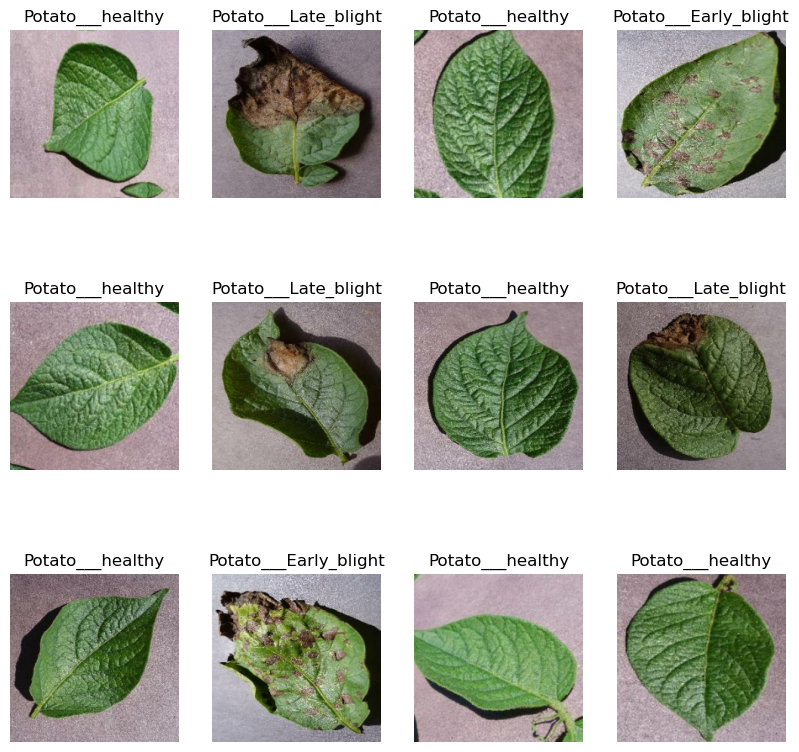

In [5]:
plt.figure(figsize=(10, 10))

for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

### Split into train / validation / test (80 / 10 / 10)

In [6]:
def get_dataset_partitions(ds, train_split=0.8, val_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions(dataset)

print(len(train_ds), len(val_ds), len(test_ds))

69 8 10


### Cache and prefetch (speeds up training)

In [7]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds  = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

### On-the-fly data augmentation

We don't need a Rescaling layer here because the MobileNetV2 `preprocess_input` function will handle the normalization (it scales pixels to the range [-1, 1] which is what MobileNetV2 expects).

In [8]:
data_augmentation = Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

### Build the model with MobileNetV2 (transfer learning)

We load MobileNetV2 with weights pre-trained on ImageNet, without its original top classifier (`include_top=False`), and freeze it (`trainable=False`). Then we add our own small classifier head on top: GlobalAveragePooling2D + Dense(64) + Dense(3, softmax) for the 3 classes.

Using the Functional API here (not Sequential) so we can pass `training=False` to the base model, to keep the batch-norm layers in inference mode during our training.

In [9]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=input_shape)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(n_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,163 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compile

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train the model

Note: this is much faster than the CNN baseline because most of the weights are frozen. Only the small head (about 82k trainable parameters) is updated.

In [11]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9185 - loss: 0.2116 - val_accuracy: 0.9766 - val_loss: 0.0948
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9755 - loss: 0.0667 - val_accuracy: 0.9609 - val_loss: 0.1109
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9832 - loss: 0.0495 - val_accuracy: 0.9805 - val_loss: 0.0578
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9887 - loss: 0.0368 - val_accuracy: 0.9727 - val_loss: 0.0935
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9823 - loss: 0.0457 - val_accuracy: 0.9844 - val_loss: 0.0388
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9887 - loss: 0.0313 - val_accuracy: 0.9766 - val_loss: 0.0680
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9837 - loss: 0.0422 - val_accuracy: 0.9766 - val_loss: 0.0584
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9923 - loss: 0.0247 - val_accuracy: 0.9883 - val_loss:

### Plot accuracy and loss curves

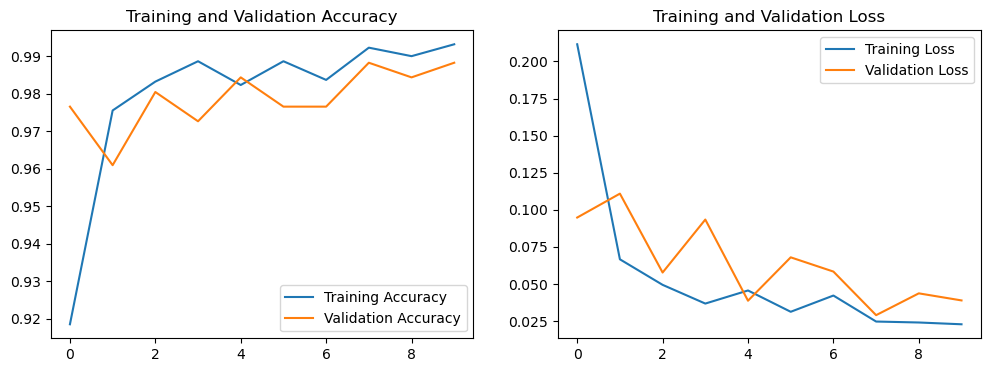

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

### Predict on sample images

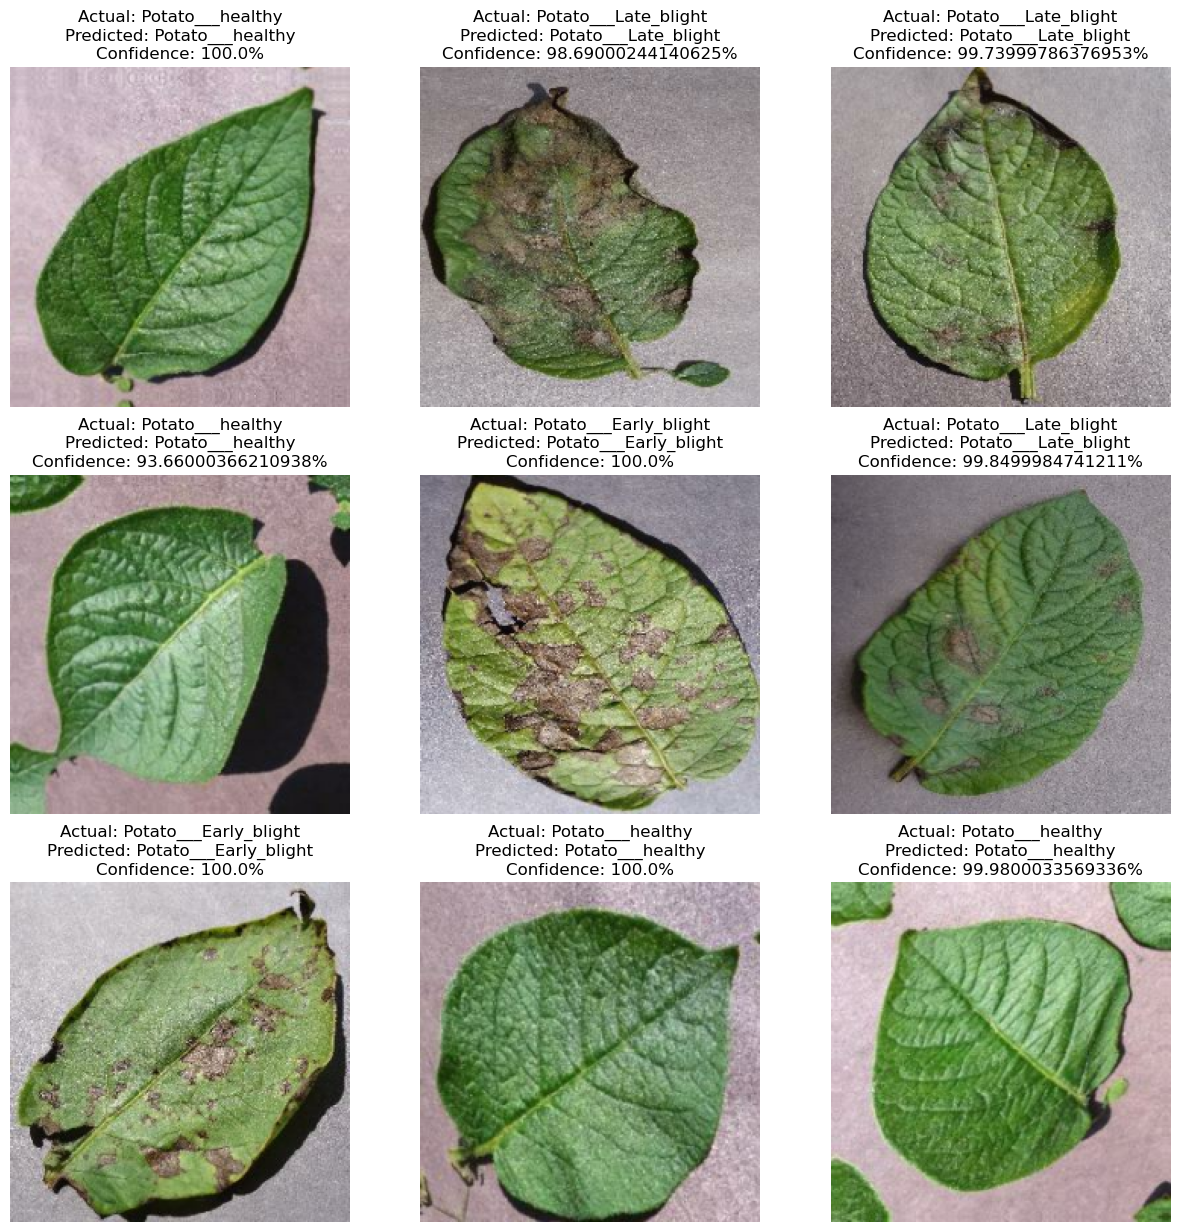

In [13]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
        plt.axis("off")

### Evaluate on test set and save the model

In [14]:
scores = model.evaluate(test_ds)
print(scores)

model.save("potato_model_mobilenetv2.h5")

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 537ms/step - accuracy: 1.0000 - loss: 0.0080


[0.008018075488507748, 1.0]


### Confusion matrix and classification report

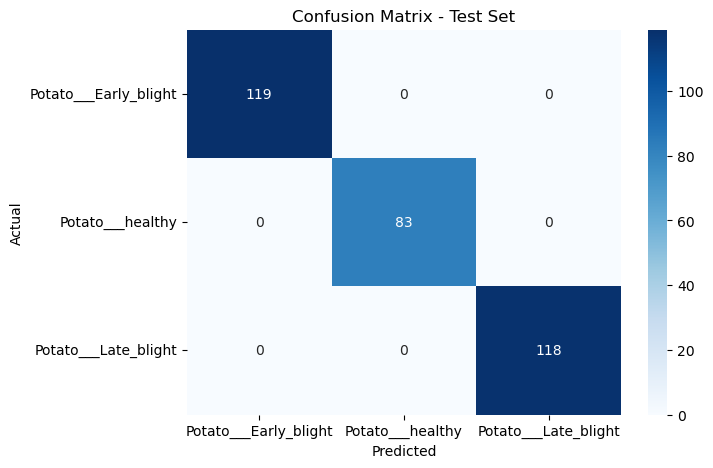

                       precision    recall  f1-score   support

Potato___Early_blight       1.00      1.00      1.00       119
     Potato___healthy       1.00      1.00      1.00        83
 Potato___Late_blight       1.00      1.00      1.00       118

             accuracy                           1.00       320
            macro avg       1.00      1.00      1.00       320
         weighted avg       1.00      1.00      1.00       320



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

### Convert to TFLite (will run after Prof. Sheta's review)

Once the model is approved we will run the conversion below to produce the `.tflite` file for the mobile app. Keeping it commented out for now to avoid generating a file that might still need changes.

In [16]:
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
# tflite_model = converter.convert()
#
# with open("potato_model_mobilenetv2.tflite", "wb") as f:
#     f.write(tflite_model)
#
# print("TFLite saved.")

### Results

Test accuracy: **98.91%** (vs 94.57% with the previous CNN baseline)
Test loss: 0.0398
Best validation accuracy: 99.61% (epoch 8 and 10)
Final training accuracy: 99.42%
Total parameters: 2,340,163 - but only 82,179 are trainable (the head). The rest comes from the frozen MobileNetV2 base.
Training time: about 14 minutes for 10 epochs on CPU.

Compared to the custom CNN, the MobileNetV2 model gives a clear improvement (+4.34% in test accuracy) and the training is also a bit faster even with bigger image size, because most of the weights are frozen.

Next step: discuss the result with Prof. Sheta then convert the model to TFLite to handover to my partner for the mobile app.